# 📊 Sales / Superstore Data — EDA & Visualization
### CodeAlpha Internship | Data Analytics

**Tasks Covered:**
- ✅ Task 2: Exploratory Data Analysis (EDA)
- ✅ Task 3: Data Visualization

**Student Name:** *(tahir mehdi)*

---

## 📦 Step 1: Libraries Import Karo

In [1]:
# Colab mein yeh sab already installed hain!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print('✅ Sari libraries import ho gayi!')

✅ Sari libraries import ho gayi!


## 📥 Step 2: Dataset Banao

> ⚠️ Koi file upload nahi karni — dataset automatically ban jayega!

In [2]:
np.random.seed(42)
n = 1000

categories = ['Technology', 'Furniture', 'Office Supplies']
sub_cats = {
    'Technology':      ['Phones', 'Computers', 'Accessories', 'Copiers'],
    'Furniture':       ['Chairs', 'Tables', 'Bookcases', 'Furnishings'],
    'Office Supplies': ['Binders', 'Paper', 'Storage', 'Appliances']
}
regions    = ['East', 'West', 'Central', 'South']
segments   = ['Consumer', 'Corporate', 'Home Office']
ship_modes = ['Standard Class', 'Second Class', 'First Class', 'Same Day']

cat_col  = np.random.choice(categories, n, p=[0.35, 0.30, 0.35])
sub_col  = [np.random.choice(sub_cats[c]) for c in cat_col]
region   = np.random.choice(regions,   n, p=[0.28, 0.30, 0.22, 0.20])
segment  = np.random.choice(segments,  n, p=[0.52, 0.30, 0.18])
ship     = np.random.choice(ship_modes,n, p=[0.60, 0.20, 0.15, 0.05])

base_sales = {'Technology': 400, 'Furniture': 350, 'Office Supplies': 120}
sales    = np.array([abs(np.random.normal(base_sales[c], base_sales[c]*0.5)) for c in cat_col])
discount = np.round(np.random.choice([0, 0.1, 0.2, 0.3, 0.4, 0.5], n, p=[0.4,0.2,0.2,0.1,0.07,0.03]), 2)
profit_margin = np.where(discount > 0.3, -0.05, np.random.uniform(0.05, 0.35, n))
profit   = np.round(sales * profit_margin, 2)
quantity = np.random.randint(1, 10, n)
dates    = pd.to_datetime(np.sort(np.random.choice(
               pd.date_range('2021-01-01','2023-12-31', periods=n), n, replace=False)))

df = pd.DataFrame({
    'Order Date'  : dates,
    'Category'    : cat_col,
    'Sub-Category': sub_col,
    'Region'      : region,
    'Segment'     : segment,
    'Ship Mode'   : ship,
    'Sales'       : np.round(sales, 2),
    'Quantity'    : quantity,
    'Discount'    : discount,
    'Profit'      : profit
})
df['Year']      = df['Order Date'].dt.year
df['Month']     = df['Order Date'].dt.month_name()
df['Month_Num'] = df['Order Date'].dt.month

print(f'✅ Dataset ready! {df.shape[0]} rows aur {df.shape[1]} columns')
df.head(10)

✅ Dataset ready! 1000 rows aur 13 columns


,Order Date,Category,Sub-Category,Region,Segment,Ship Mode,Sales,Quantity,Discount,Profit,Year,Month,Month_Num
0,2021-01-01 00:00:00.000000000,Furniture,Bookcases,West,Home Office,Standard Class,410.67,1,0.0,98.90,2021,January,1
1,2021-01-02 02:16:56.216216216,Office Supplies,Appliances,West,Corporate,First Class,270.69,5,0.2,26.91,2021,January,1
2,2021-01-03 04:33:52.432432432,Office Supplies,Paper,East,Corporate,Same Day,9.60,3,0.0,1.72,2021,January,1
3,2021-01-04 06:50:48.648648648,Furniture,Furnishings,West,Home Office,Standard Class,344.35,7,0.0,46.89,2021,January,1
4,2021-01-05 09:07:44.864864864,Technology,Copiers,West,Consumer,First Class,528.11,3,0.2,143.14,2021,January,1
5,2021-01-06 11:24:41.081081081,Technology,Accessories,West,Consumer,Second Class,424.62,5,0.0,78.99,2021,January,1
6,2021-01-07 13:41:37.297297297,Technology,Copiers,Central,Home Office,Same Day,377.37,7,0.3,130.87,2021,January,1
7,2021-01-08 15:58:33.513513513,Office Supplies,Storage,West,Consumer,Standard Class,42.05,3,0.0,2.79,2021,January,1
8,2021-01-09 18:15:29.729729729,Furniture,Chairs,Central,Home Office,First Class,390.74,2,0.2,61.15,2021,January,1
9,2021-01-10 20:32:25.945945946,Office Supplies,Binders,Central,Home Office,Standard Class,74.59,6,0.1,14.51,2021,January,1


## 🔍 Step 3: Exploratory Data Analysis (EDA) — Task 2

In [3]:
print('=' * 50)
print('📐 Dataset ka Size (Shape)')
print(f'   Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')

print('\n📋 Columns aur Data Types:')
print(df.dtypes)

print('\n❓ Missing Values (Khaali cells):')
print(df.isnull().sum())

print('\n📊 Statistical Summary:')
display(df[['Sales','Profit','Quantity','Discount']].describe().round(2))

📐 Dataset ka Size (Shape)
   Rows: 1000  |  Columns: 13

📋 Columns aur Data Types:
Order Date      datetime64[ns]
Category                object
Sub-Category            object
Region                  object
Segment                 object
Ship Mode               object
Sales                  float64
Quantity                 int64
Discount               float64
Profit                 float64
Year                     int32
Month                   object
Month_Num                int32
dtype: object

❓ Missing Values (Khaali cells):
Order Date      0
Category        0
Sub-Category    0
Region          0
Segment         0
Ship Mode       0
Sales           0
Quantity        0
Discount        0
Profit          0
Year            0
Month           0
Month_Num       0
dtype: int64

📊 Statistical Summary:


,Sales,Profit,Quantity,Discount
count,1000.00,1000.00,1000.00,1000.00
mean,285.99,48.53,5.05,0.13
std,192.32,49.33,2.54,0.14
min,0.27,-51.52,1.00,0.00
25%,126.08,14.84,3.00,0.00
50%,247.94,36.30,5.00,0.10
75%,431.79,72.14,7.00,0.20
max,1048.62,257.34,9.00,0.50


In [4]:
print('💰 Category wise Total Sales:')
display(df.groupby('Category')['Sales'].sum().round(2).to_frame())

print('\n📍 Region wise Total Profit:')
display(df.groupby('Region')['Profit'].sum().round(2).to_frame())

print('\n👥 Orders by Segment:')
display(df['Segment'].value_counts().to_frame())

print('\n🚚 Orders by Ship Mode:')
display(df['Ship Mode'].value_counts().to_frame())

💰 Category wise Total Sales:


,Sales
Category,
Furniture,101624.30
Office Supplies,39265.11
Technology,145096.72



📍 Region wise Total Profit:


,Profit
Region,
Central,12686.85
East,12387.87
South,8860.22
West,14596.66



👥 Orders by Segment:


,count
Segment,
Consumer,513
Corporate,316
Home Office,171



🚚 Orders by Ship Mode:


,count
Ship Mode,
Standard Class,633
Second Class,174
First Class,146
Same Day,47


## 📈 Step 4: Data Visualization — Task 3

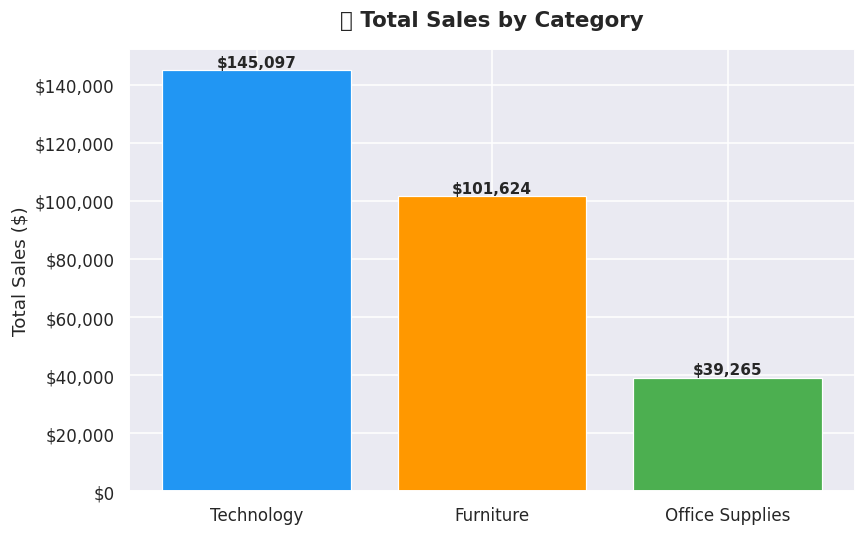

✅ Chart 1 complete!


In [5]:
# ── Chart 1: Sales by Category
fig, ax = plt.subplots(figsize=(8, 5))
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
bars = ax.bar(cat_sales.index, cat_sales.values,
              color=['#2196F3','#FF9800','#4CAF50'], edgecolor='white', linewidth=0.8)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f'${bar.get_height():,.0f}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('💰 Total Sales by Category', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Sales ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.show()
print('✅ Chart 1 complete!')

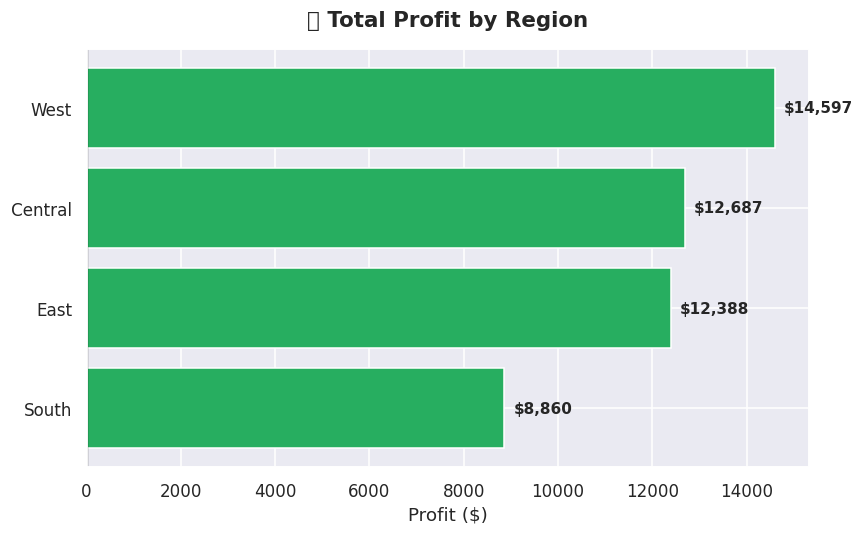

✅ Chart 2 complete!


In [6]:
# ── Chart 2: Profit by Region
fig, ax = plt.subplots(figsize=(8, 5))
reg_profit = df.groupby('Region')['Profit'].sum().sort_values()
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in reg_profit.values]
bars = ax.barh(reg_profit.index, reg_profit.values, color=colors, edgecolor='white')
for bar, val in zip(bars, reg_profit.values):
    ax.text(val + 200, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')
ax.set_title('📍 Total Profit by Region', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Profit ($)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print('✅ Chart 2 complete!')

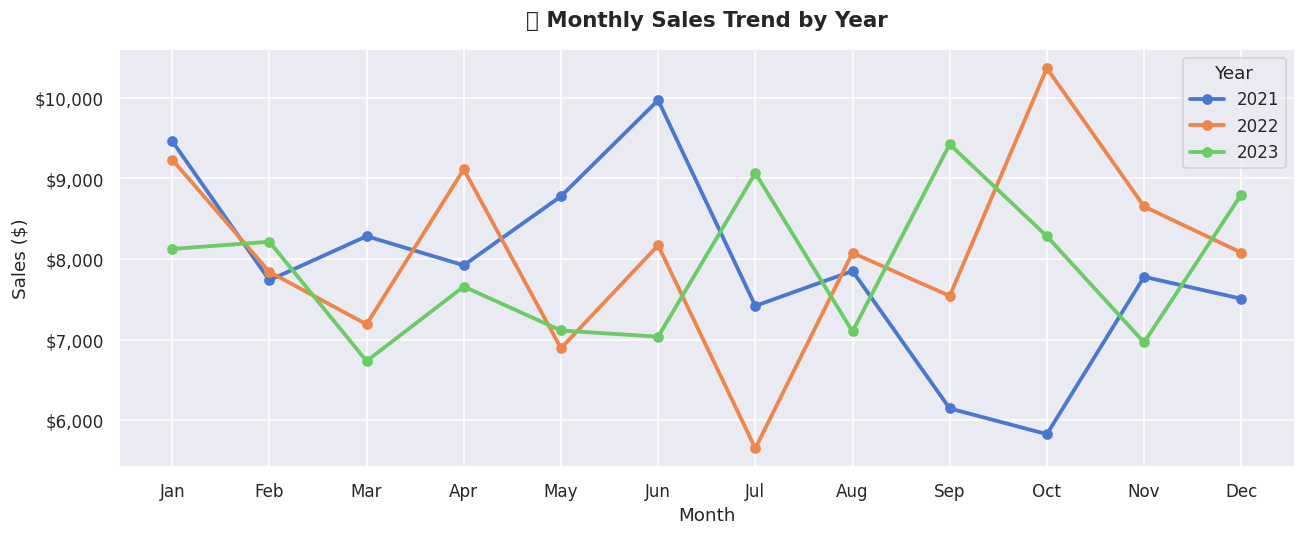

✅ Chart 3 complete!


In [7]:
# ── Chart 3: Monthly Sales Trend
monthly = df.groupby(['Year','Month_Num'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime({'year': monthly['Year'], 'month': monthly['Month_Num'], 'day': 1})
monthly = monthly.sort_values('Date')

fig, ax = plt.subplots(figsize=(12, 5))
for yr, grp in monthly.groupby('Year'):
    ax.plot(grp['Month_Num'], grp['Sales'], marker='o', linewidth=2.5, label=str(yr))
ax.set_title('📅 Monthly Sales Trend by Year', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.legend(title='Year')
plt.tight_layout()
plt.show()
print('✅ Chart 3 complete!')

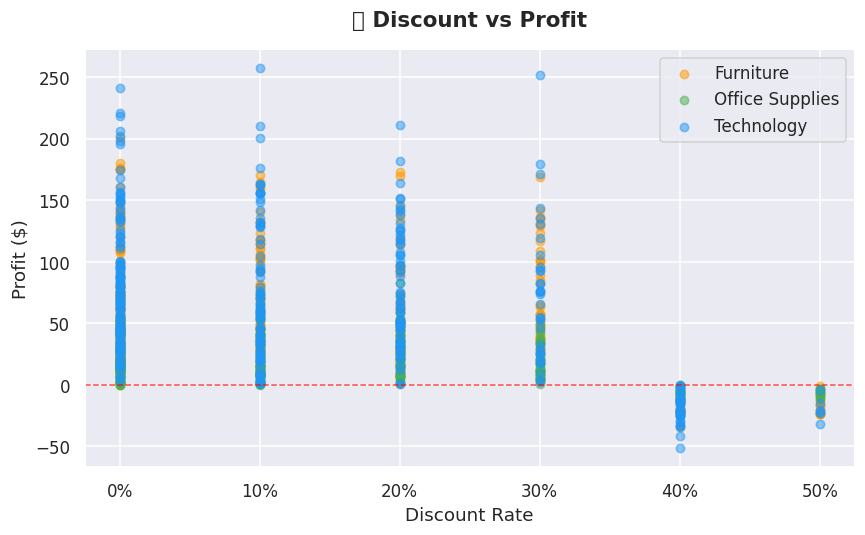

✅ Chart 4 complete!


In [8]:
# ── Chart 4: Discount vs Profit
fig, ax = plt.subplots(figsize=(8, 5))
colors_cat = {'Technology':'#2196F3','Furniture':'#FF9800','Office Supplies':'#4CAF50'}
for cat, grp in df.groupby('Category'):
    ax.scatter(grp['Discount'], grp['Profit'], alpha=0.5, s=30,
               label=cat, color=colors_cat[cat])
ax.axhline(0, color='red', linewidth=1, linestyle='--', alpha=0.7)
ax.set_title('🔎 Discount vs Profit', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit ($)')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()
print('✅ Chart 4 complete!')

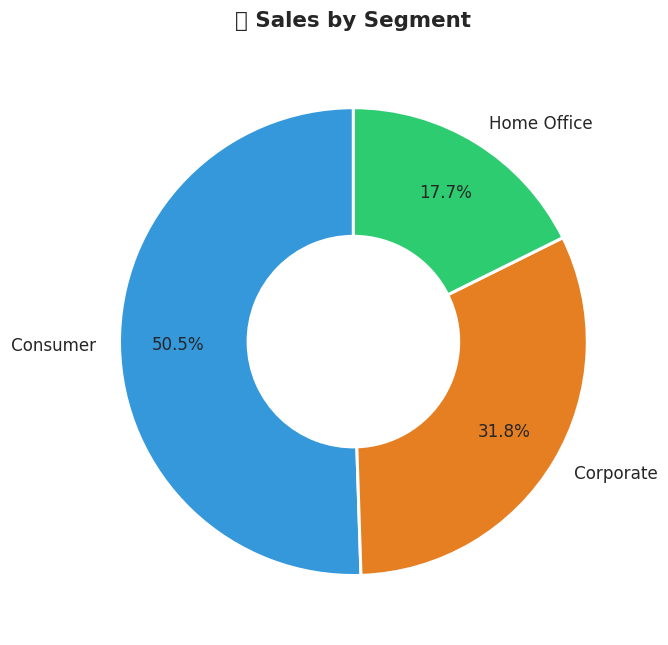

✅ Chart 5 complete!


In [9]:
# ── Chart 5: Sales by Segment (Pie)
fig, ax = plt.subplots(figsize=(7, 6))
seg_sales = df.groupby('Segment')['Sales'].sum()
ax.pie(seg_sales, labels=seg_sales.index, autopct='%1.1f%%',
       colors=['#3498db','#e67e22','#2ecc71'],
       wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2),
       startangle=90, pctdistance=0.75)
ax.set_title('🧩 Sales by Segment', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('✅ Chart 5 complete!')

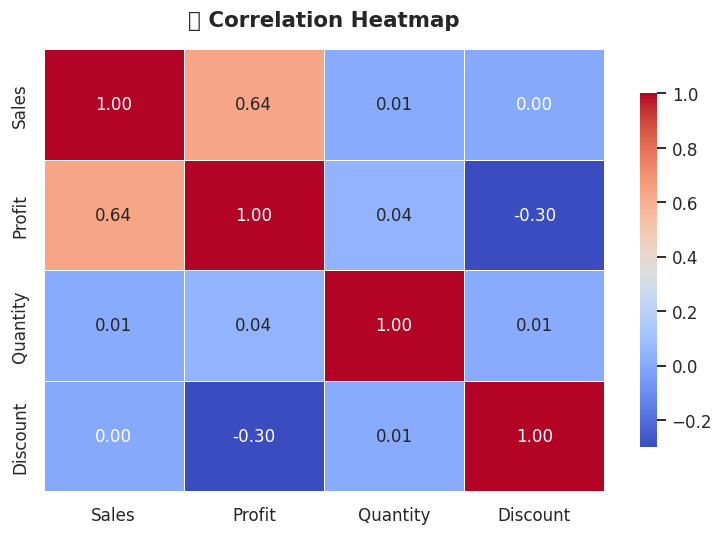

✅ Chart 6 complete!


In [10]:
# ── Chart 6: Correlation Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[['Sales','Profit','Quantity','Discount']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('🔥 Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
print('✅ Chart 6 complete!')

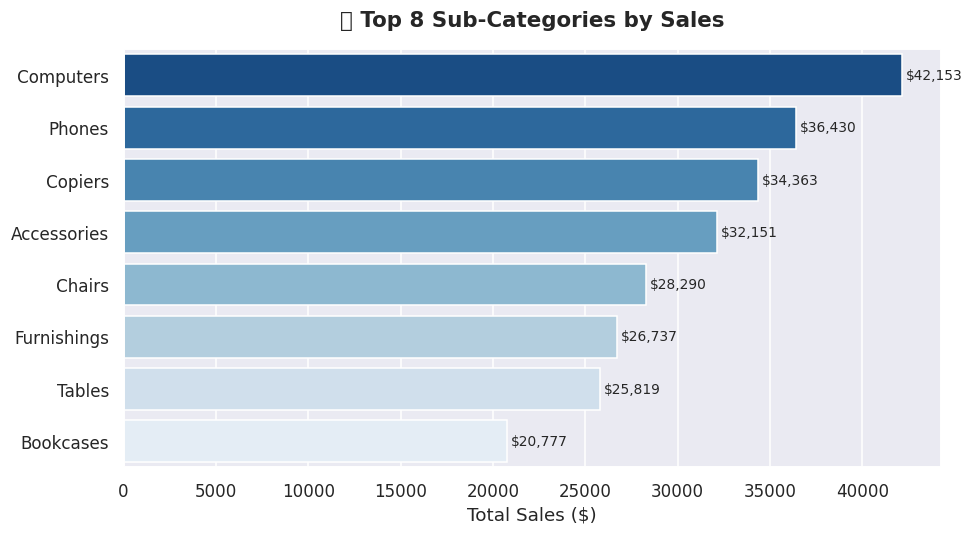

✅ Chart 7 complete!


In [11]:
# ── Chart 7: Top Sub-Categories by Sales
fig, ax = plt.subplots(figsize=(9, 5))
top_sub = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(8)
sns.barplot(x=top_sub.values, y=top_sub.index, palette='Blues_r', ax=ax)
for i, val in enumerate(top_sub.values):
    ax.text(val + 200, i, f'${val:,.0f}', va='center', fontsize=9)
ax.set_title('🏆 Top 8 Sub-Categories by Sales', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
print('✅ Chart 7 complete!')

## 📝 Step 5: Key Insights & Conclusions

In [12]:
best_cat     = df.groupby('Category')['Sales'].sum().idxmax()
best_region  = df.groupby('Region')['Profit'].sum().idxmax()
worst_region = df.groupby('Region')['Profit'].sum().idxmin()
top_segment  = df.groupby('Segment')['Sales'].sum().idxmax()
high_disc    = df[df['Discount'] >= 0.4]['Profit'].mean()
low_disc     = df[df['Discount'] == 0]['Profit'].mean()

print('=' * 55)
print('📊 KEY INSIGHTS — SUPERSTORE SALES ANALYSIS')
print('=' * 55)
print(f'  🏆 Highest Selling Category  : {best_cat}')
print(f'  📍 Most Profitable Region    : {best_region}')
print(f'  ⚠️  Least Profitable Region   : {worst_region}')
print(f'  👥 Top Customer Segment      : {top_segment}')
print(f'  💸 Avg Profit (Discount≥40%) : ${high_disc:,.2f}')
print(f'  💰 Avg Profit (No Discount)  : ${low_disc:,.2f}')
print('=' * 55)
print()
print('📌 CONCLUSIONS:')
print('  1. Technology category has the highest total sales.')
print('  2. High discounts (40%+) significantly reduce profit.')
print(f'  3. {best_region} region generates the most profit.')
print('  4. Consumer segment drives the most revenue.')
print('  5. Discount and Profit are negatively correlated.')
print()
print('✅ Analysis complete! Dono tasks successfully ho gaye!')

📊 KEY INSIGHTS — SUPERSTORE SALES ANALYSIS
  🏆 Highest Selling Category  : Technology
  📍 Most Profitable Region    : West
  ⚠️  Least Profitable Region   : South
  👥 Top Customer Segment      : Consumer
  💸 Avg Profit (Discount≥40%) : $-14.95
  💰 Avg Profit (No Discount)  : $55.71

📌 CONCLUSIONS:
  1. Technology category has the highest total sales.
  2. High discounts (40%+) significantly reduce profit.
  3. West region generates the most profit.
  4. Consumer segment drives the most revenue.
  5. Discount and Profit are negatively correlated.

✅ Analysis complete! Dono tasks successfully ho gaye!
